In [1]:
import ROOT
import matplotlib.pyplot as plt
import numpy as np
DAQ_FRQ = 30.3030303030e6
QDB_FRQ = 30e6
ROOT.EnableImplicitMT()
ana_file = "./data/tileAna.root"
slow_file = "./data/acquire0p1Hz.root"
fast_file = "./data/acquire4p0Hz.root"

Welcome to JupyROOT 6.27/01


In [2]:
tf = ROOT.TFile("./data/tileAna.root", "READ")
tf.qdbData.Print()

******************************************************************************
*Tree    :qdbData   : data_tree                                              *
*Entries :    46683 : Total =          705320 bytes  File  Size =     401537 *
*        :          : Tree compression factor =   1.75                       *
******************************************************************************
*Br    0 :trgT      : trgT/i                                                 *
*Entries :    46683 : Total  Size=     187657 bytes  File Size  =      18086 *
*Baskets :        6 : Basket Size=      32000 bytes  Compression=  10.35     *
*............................................................................*
*Br    1 :daqT      : daqT/i                                                 *
*Entries :    46683 : Total  Size=     187657 bytes  File Size  =     182377 *
*Baskets :        6 : Basket Size=      32000 bytes  Compression=   1.03     *
*...................................................

In [3]:
def makeRTDs(arr):
    arr = np.array(arr, dtype=np.double)
    rtd = [ arr[i+1] - arr[i] for i in range(len(arr)-1) ]
    rtd = np.array([ r if r >= 0 else r+2**32 for r in rtd ], dtype=np.double)
    return rtd

In [4]:
def makeASICData(input_file):
    rdf = ROOT.RDataFrame("qdbData", input_file)
    data = rdf.AsNumpy()

    daq_t = data["daqT"]
    trgT = data["trgT"]
    asic_t = data["asicT"]

    words = data["wordType"]
    asic_x = data["asicX"]
    asic_y = data["asicY"]
    words = np.array([ ord(w) for w in words ])
    asic_x = [ ord(x) for x in asic_x ]
    asic_y = [ ord(y) for y in asic_y ]

    unique_asic_x = np.unique(asic_x)
    unique_asic_y = np.unique(asic_y)

    print("found x's:", unique_asic_x)
    print("found y's:", unique_asic_y)
    nTrigs = np.unique(trgT)
    print(f"found nTrigs: {len(nTrigs)}")
    daqTrigs = np.unique(daq_t)
    print(f"found daqTrigs: {len(daqTrigs)}")
    asicTrigs = np.unique(asic_t)
    print(f"found asicTrigs: {len(asicTrigs)}")
    
    asic_data = {}

    for x in unique_asic_x:
        for y in unique_asic_y:
            good_ind = np.logical_and(asic_x == x, asic_y == y)
            asic_data[f"({x},{y})"] = { "wordType":words[good_ind],
                                        "daqT":daq_t[good_ind],
                                        "trgT":trgT[good_ind],
                                        "asicT":asic_t[good_ind]
                                      }
    return asic_data

In [5]:
def calc_frqs(aData):

    asicFrqs = {}
    asicPacketT = {}
    
    for asic_key, data in aData.items():

        evtEndInd = data["wordType"] == 5
        dataInd = data["wordType"] == 1
        
        # event end words
        endTimes = data["asicT"][evtEndInd]
        trgTimes = data["trgT"][evtEndInd]
        daqTimes = np.array(data["daqT"][evtEndInd], dtype=np.double)
        
        asicFrq = DAQ_FRQ * ( makeRTDs(endTimes) / makeRTDs(trgTimes) )

        recall_time = [ daqT - trgT for daqT, trgT in zip(daqTimes, trgTimes) ]
        recall_time = [ r if r > 0 else r+2**32 for r in recall_time ]
        
        # calcFrq = np.mean(asicFrq)
        # print(asic_key, f"has data words: {np.count_nonzero(dataInd)}")
        # print(f"calculated frq: {calcFrq} +/- {np.std(asicFrq)}")
        
        asicFrqs[asic_key] = asicFrq
        asicPacketT[asic_key] = recall_time
        
    return asicFrqs, asicPacketT
    
        # data word ana
        # evtTimes = data["asicT"][dataInd]
        # print(f"found {len(evtTimes)} data words")
        # evtRTDs = makeRTDs(evtTimes) 
        # size = len(evtRTDs)
        # if size > 0:
        #     evtRTDs = evtRTDs/calcFrq
        #     print(f"calculated {size} rtds: {np.mean(evtRTDs)} +/- {np.std(evtRTDs)}")

        # daqT word ana
        # if size == 0:
        #     daqTimes = data["daqT"][evtEndInd]
        #     delayT = daqTimes - trgTimes
        #     print(delayT[:20], len(delayT))
        #     print(f"calculated frq: {np.mean(delayT[:15])} +/- {np.std(delayT[:15])}")

### Test Daq Data

In [6]:
rdf_fast = ROOT.RDataFrame("qdbData", fast_file)
rdf_slow = ROOT.RDataFrame("qdbData", slow_file)

rdf_fast_data = rdf_fast.AsNumpy()
rdf_slow_data = rdf_slow.AsNumpy()

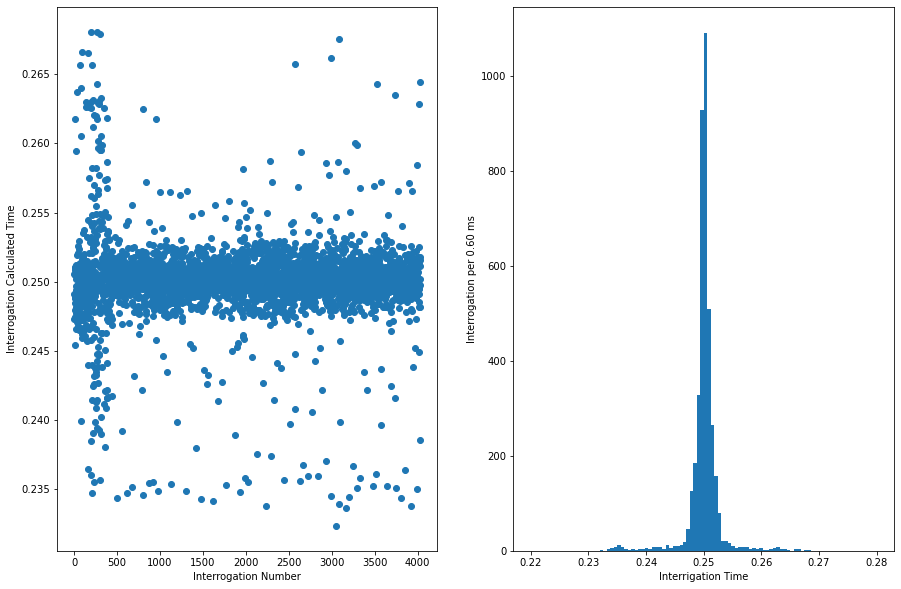

In [7]:
rdf_fast_trg = rdf_fast_data['trgT']
rdf_fast_trg_rtd = makeRTDs(rdf_fast_trg)
rdf_fast_trg_t = rdf_fast_trg_rtd[rdf_fast_trg_rtd != 0]/DAQ_FRQ
x = np.arange(1, len(rdf_fast_trg_t)+1)
fig, ax = plt.subplots(1,2,figsize=(15,10))
ax[0].scatter(x, rdf_fast_trg_t)
ax[0].set_xlabel("Interrogation Number")
ax[0].set_ylabel("Interrogation Calculated Time")
ax[1].hist(rdf_fast_trg_t, bins=100, range=(0.22,0.28))
ax[1].set_xlabel("Interrigation Time")
bin_size = (0.28 - 0.22) / 100
ax[1].set_ylabel(f"Interrogation per {bin_size*1e3:0.2f} ms")
fig.savefig("./pdfs/interrogation_dist.pdf")

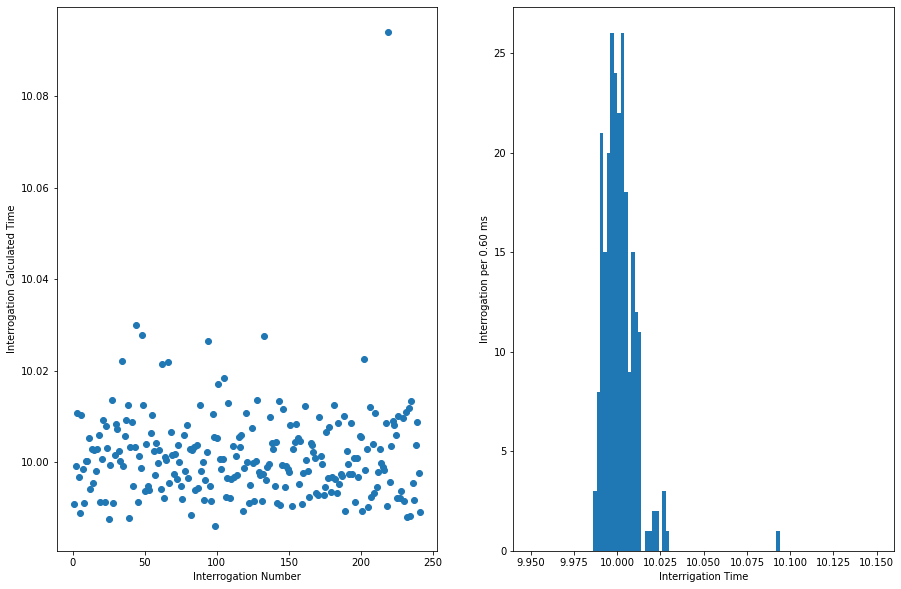

In [8]:
rdf_slow_trg = rdf_slow_data['trgT']
rdf_slow_trg_rtd = makeRTDs(rdf_slow_trg)
rdf_slow_trg_t = rdf_slow_trg_rtd[rdf_slow_trg_rtd != 0]/DAQ_FRQ
x = np.arange(1, len(rdf_slow_trg_t)+1)
fig, ax = plt.subplots(1,2,figsize=(15,10))
ax[0].scatter(x, rdf_slow_trg_t)
ax[0].set_xlabel("Interrogation Number")
ax[0].set_ylabel("Interrogation Calculated Time")
ax[1].hist(rdf_slow_trg_t, bins=100, range=(9.95,10.15))
ax[1].set_xlabel("Interrigation Time")
bin_size = (0.28 - 0.22) / 100
ax[1].set_ylabel(f"Interrogation per {bin_size*1e3:0.2f} ms")
fig.savefig("./pdfs/interrogation_dist.pdf")

### Test Frq Data

In [9]:
asic_data = makeASICData(ana_file)

found x's: [0 1]
found y's: [0 1]
found nTrigs: 3363
found daqTrigs: 46683
found asicTrigs: 46683


In [10]:
slow_data = makeASICData(slow_file)

found x's: [0 1 2 3]
found y's: [0 1 2 3]
found nTrigs: 242
found daqTrigs: 3872
found asicTrigs: 3872


In [11]:
fast_data = makeASICData(fast_file)

found x's: [0 1 2 3]
found y's: [0 1 2 3]
found nTrigs: 4030
found daqTrigs: 64480
found asicTrigs: 64478


In [12]:
afrqs, apacketTs = calc_frqs(asic_data)

In [13]:
slow_frqs, slow_packetTs = calc_frqs(slow_data)

In [14]:
fast_frqs, fast_packetTs = calc_frqs(fast_data)

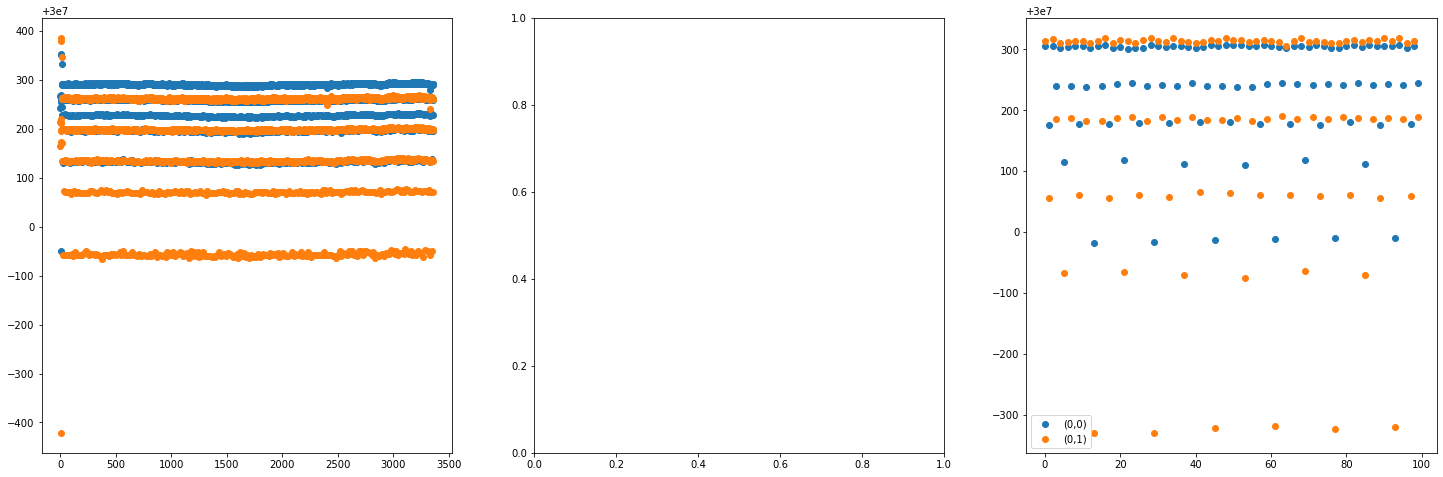

In [15]:
fig, ax = plt.subplots(1,3,figsize=(25,8))

i = 0
for k, v in afrqs.items():
    ind = np.arange(len(v))
    ax[0].scatter(ind, v)
    i += 1
    if i >= 2:
        break

i = 0


i = 0
for k, fast in fast_frqs.items():

    i += 1
    new_rtd = fast
    fast = fast[20:120]

    ind2 = np.arange(len(fast))
    # print(k, np.mean(fast))
    ax[2].scatter(ind2, fast, label=k)
    ax[2].legend()
    # print(fast[fast < 0])
    if i >= 2:
        break

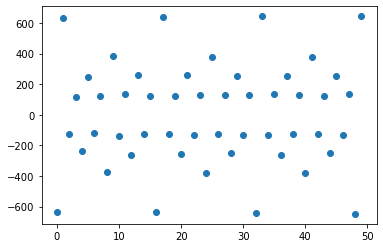

In [16]:
calc_rtd = [ new_rtd[i+1] - new_rtd[i] for i in range(len(new_rtd)-1) ]
graph_calc = calc_rtd[:50]
plt.scatter(np.arange(0, len(graph_calc)), graph_calc)

### Save Figs Here

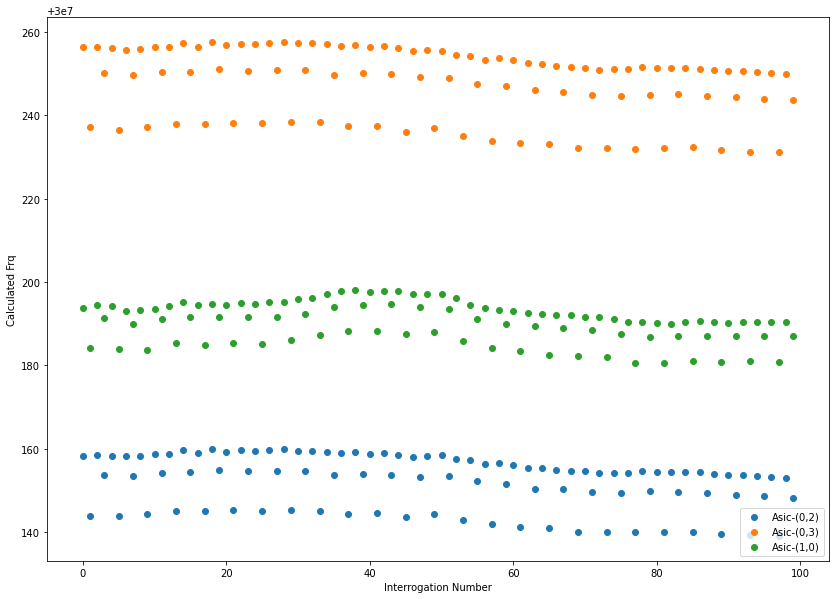

In [38]:
fig, ax = plt.subplots(figsize=(14,10))
i = 0
for k, slow in slow_frqs.items():

    i += 1
    
    if i <= 2:
        continue
    
    slow = slow[40:140]
    ind1 = np.arange(len(slow))
    ax.scatter(ind1, slow, label=f"Asic-{k}")
    ax.legend(loc="lower right")
    ax.set_xlabel("Interrogation Number")
    ax.set_ylabel("Calculated Frq")
    if i >= 5:
        break
plt.savefig("./pdfs/slow_example.pdf")

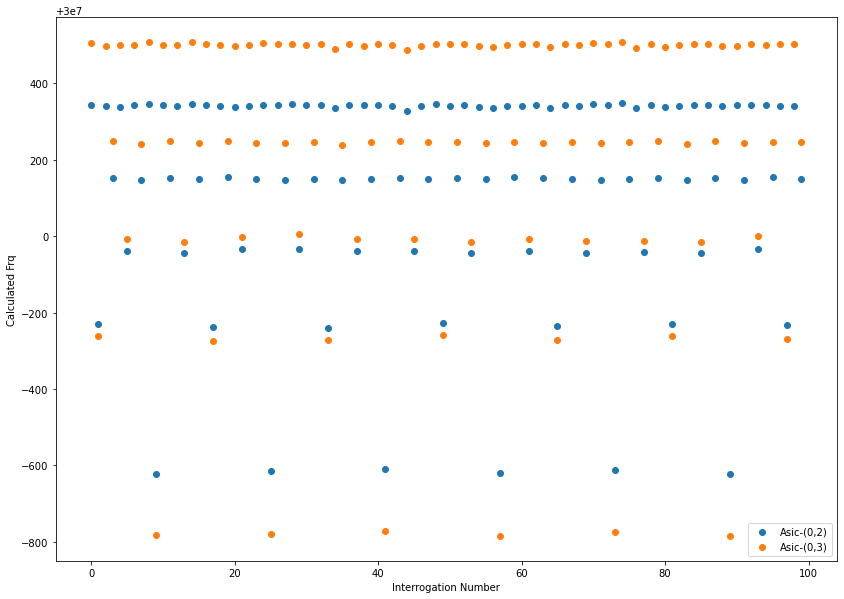

In [39]:
fig, ax = plt.subplots(figsize=(14,10))
i = 0
for k, slow in fast_frqs.items():

    i += 1
    
    if i <= 2:
        continue
    
    slow = slow[40:140]
    ind1 = np.arange(len(slow))
    ax.scatter(ind1, slow, label=f"Asic-{k}")
    ax.legend(loc="lower right")

    ax.set_xlabel("Interrogation Number")
    ax.set_ylabel("Calculated Frq")
    if i >= 4:
        break
plt.savefig("./pdfs/fast_example.pdf")

[-393.1538778  -239.32136104  218.02087984  264.74175219  -43.13311732] [124.65620310977101, -512.362842861563, 121.39100331068039, -2.674981713294983, 112.35656579211354]


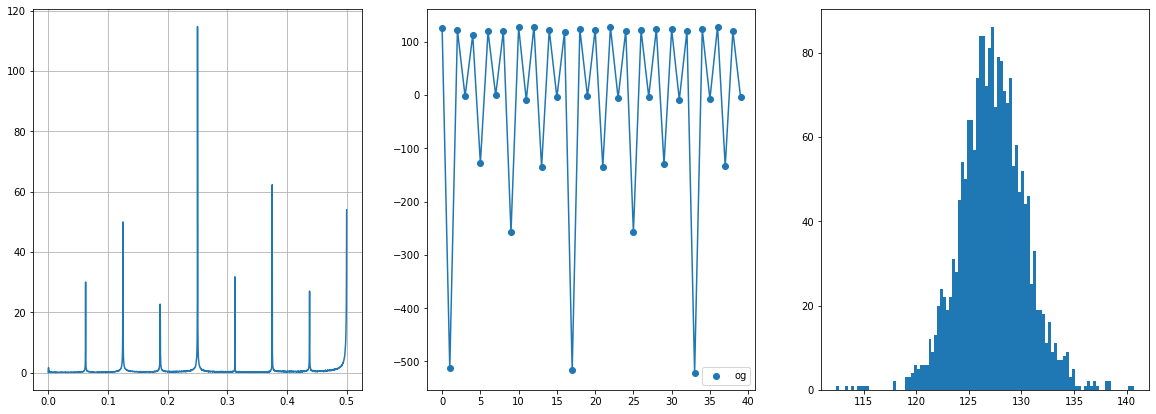

In [19]:
from scipy.fft import fft, fftfreq
import numpy as np

def smooth(y_fft):
    return [ 0 if y>10 else y for y in y_fft ]

fig, ax = plt.subplots(1,3,figsize=(20,7))

m = np.mean(new_rtd)
fft_data = [ r-m for r in new_rtd ]

# Number of sample points
N = len(fft_data)
# sample spacing
T = 1.0
x = np.linspace(0.0, N*T, N, endpoint=False)
y = fft_data

yf = np.fft.rfft(y)
xf = np.fft.rfftfreq(N, T)[:N//2]

# smoothing here
yr = np.fft.irfft(smooth(yf))
# xr = np.fft.rfftfreq(xf)

import matplotlib.pyplot as plt
ax[0].plot(xf, 2.0/N * np.abs(yf[0:N//2]))
ax[0].grid()

ax[1].scatter(x[:40], y[:40], label="og")
ax[1].plot(x[:40], y[:40])
# print(len(x), len(yr))
# ax[1].scatter(x[:40], yr[:40])
print(yr[:5], y[:5])
ax[1].legend()

y = np.array(y, dtype=np.double)
ny = y[y>50]

# ax[2].hist(2.0/N * np.abs(yf[0:N//2]), bins=(40), range=(0,10), log=True)
ax[2].hist(ny, bins=100)

plt.show()

found fast mean: 30000245.542867467
found fast mean: 30000190.645779517
found fast mean: 30000153.908262268
found fast mean: 30000248.831021577
found fast mean: 30000192.72909397
found fast mean: 30000210.904544435
found fast mean: 30000116.212453548
found fast mean: 30000159.824462105
found fast mean: 30000351.4310422
found fast mean: 30000193.844724547
found fast mean: 30000200.277851727
found fast mean: 30000152.632703904
found fast mean: 30000183.358769394
found fast mean: 30000209.788163595
found fast mean: 30000192.276898105
found fast mean: 30000171.30200954


Error in <TROOT::SetStyle>: Unknown style:BELLEII
Info in <TCanvas::Print>: pdf file ./pdfs/(0,0).pdf has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: pdf file ./pdfs/(0,1).pdf has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: pdf file ./pdfs/(0,2).pdf has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: pdf file ./pdfs/(0,3).pdf has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: pdf file ./pdfs/(1,0).pdf has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: pdf file ./pdfs/(1,1).pdf has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: pdf file ./pdfs/(1,2).pdf has been created
Warning in <TCanvas::Constructor>: Deleting canvas wi

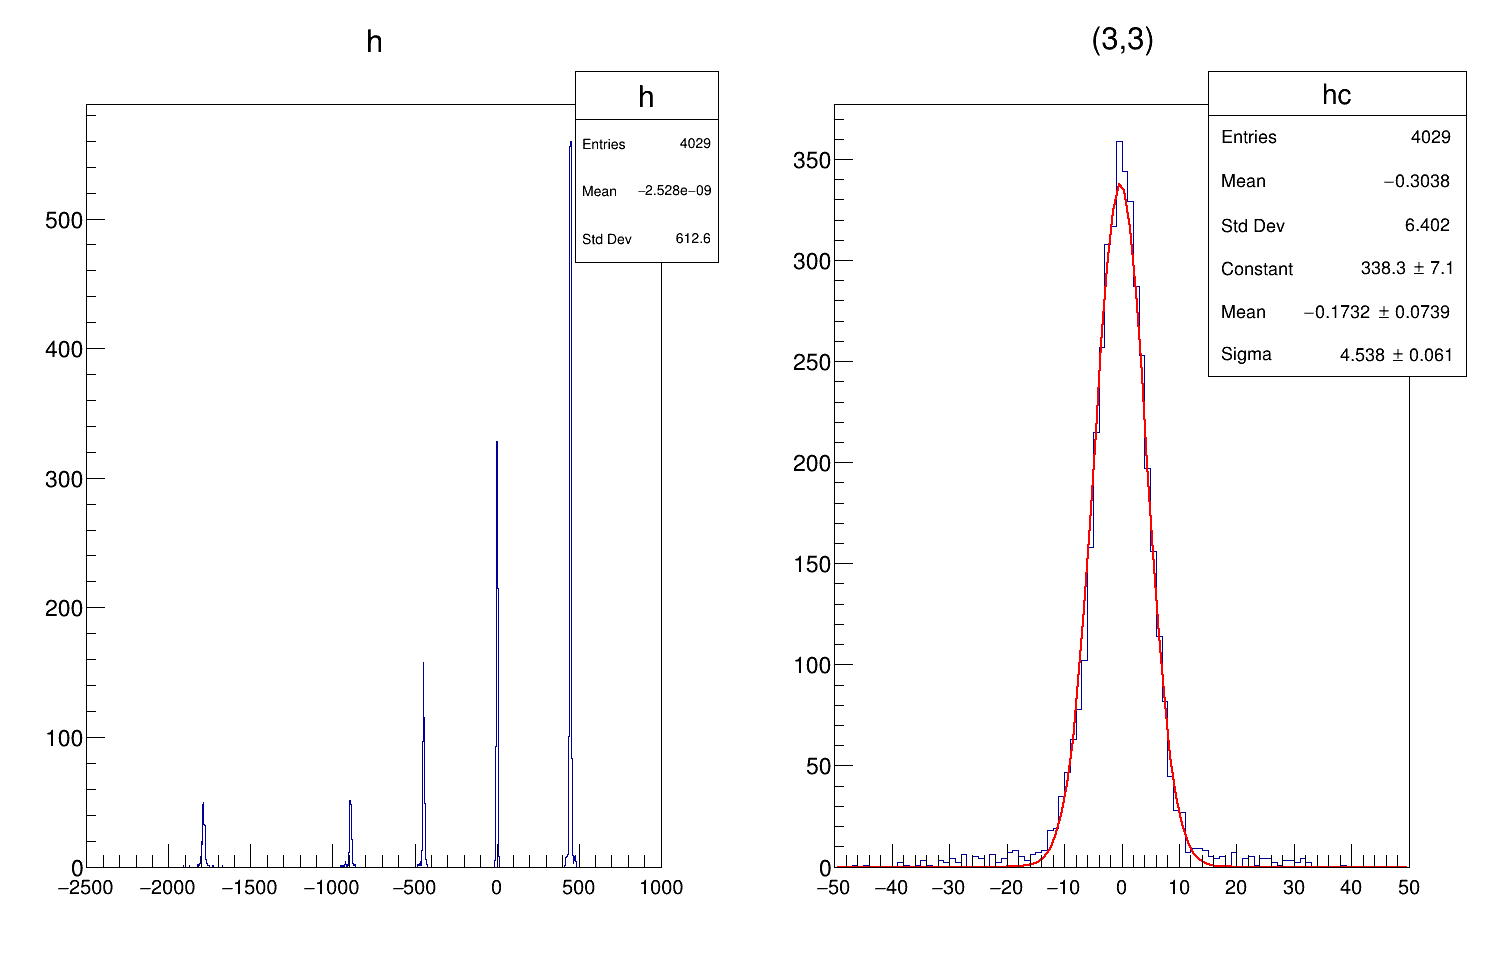

In [20]:
from texttable import Texttable
import latextable

table_digi_buf = Texttable()
table_digi_buf.set_cols_align(["c", "c", "c", "c"])
table_digi_buf_data = [["FPGA Position", "Mean", "STD", "$\\frac{\\delta f}{f_{o}}$*1e6 (ppm)"]]

ROOT.gROOT.SetStyle("BELLEII")
ROOT.gStyle.SetOptFit(11)
ROOT.gStyle.SetLabelSize(0.03)
for k, fast_data in fast_frqs.items():
    fast_m = np.mean(fast_data)
    print(f"found fast mean: {fast_m}")
    diff_data = np.array([r-fast_m for r in fast_data], dtype=np.double) 

    diff = 25 if k == "(0,0)" else 100
    # print(f"key: {k}, diff: {diff}")
    diff_data = np.sort(diff_data)
    arrs = [[]]
    curMean = diff_data[0]
    nMeans = 0
    c = ROOT.TCanvas("c", "c", 1500, 1000)
    c.Divide(2)
    c.cd(1)
    back = -1000 if k != "(3,3)" else -2500
    h = ROOT.TH1D("h", "h", 1000, back, 1000)
    h.SetDirectory(0)
    for d in diff_data:

        if d - curMean > diff:
            arrs.append([])
            nMeans += 1
        arrs[nMeans].append(d)
        curMean = d
        h.Fill(d)

    h.Draw()
    # print(f"key: {k}, nMeans: {len(arrs)}, means: {[np.mean(arr) for arr in arrs]}")

    c.cd(2)
    ind = 0
    new_arr = []
    for mean in arrs:
        m = np.mean(mean)
        fit_hist = ROOT.TH1D("hn", "hn", 20, m-(2*diff), m+(2*diff))
        fit_hist.SetDirectory(0)
        for d in mean:
            fit_hist.Fill(d)
        
        # user the gaus fit as a center to move all of the points to the center
        fit_hist.Fit("gaus", "q")
        center = fit_hist.GetFunction("gaus").GetParameter("Mean")
        for d in mean:
            new_arr.append(d-center)
    
    comb_hist = ROOT.TH1D("hc", "hc", 100, -50, 50)
    comb_hist.SetDirectory(0)
    for nd in new_arr:
        comb_hist.Fill(nd)
    
    
    comb_hist.SetTitle(f"{k}")
    comb_hist.Fit("gaus", "q")
    
    std = comb_hist.GetFunction("gaus").GetParameter("Sigma")
    table_digi_buf_data.append([k, fast_m, std, std/fast_m * 1e6])
    
    comb_hist.Draw()
    
    c.Draw()
    c.SaveAs(f"./pdfs/{k}.pdf")
table_digi_buf.add_rows(table_digi_buf_data)
fpga_fit = latextable.draw_latex(table_digi_buf, caption="FPGA Calibration Results", label="tab:fpga_calibration")
fpga_tex_file = "./pdfs/fpga_fit.tex"
with open(fpga_tex_file, 'w') as f:
    f.write(fpga_fit)

(0,0) mean 30000243.222617082, std: 3.8951957385164078
(0,1) mean 30000187.22481173, std: 4.630980254199383
(0,2) mean 30000151.019844245, std: 6.254687694566927
(0,3) mean 30000246.553211853, std: 8.229081997150809
(1,0) mean 30000188.851128194, std: 4.520848002015281
(1,1) mean 30000207.837075174, std: 6.467916582040448
(1,2) mean 30000111.34366833, std: 7.881801099969333
(1,3) mean 30000156.660499495, std: 9.98487699653392
(2,0) mean 30000348.26325745, std: 6.7475993844296545
(2,1) mean 30000190.975692477, std: 8.621525195356615
(2,2) mean 30000196.368644673, std: 9.91881528016642
(2,3) mean 30000148.283767384, std: 11.843798429281668
(3,0) mean 30000179.717634454, std: 8.374533176499334
(3,1) mean 30000207.859462857, std: 10.655358221736961
(3,2) mean 30000188.12259159, std: 11.835995021514687
(3,3) mean 30000165.010745794, std: 13.725030815135154


Error in <TROOT::SetStyle>: Unknown style:BELLEII
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: pdf file ./pdfs/slow_(0,0).pdf has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: pdf file ./pdfs/slow_(0,1).pdf has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: pdf file ./pdfs/slow_(0,2).pdf has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: pdf file ./pdfs/slow_(0,3).pdf has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: pdf file ./pdfs/slow_(1,0).pdf has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: pdf file ./pdfs/slow_(1,1).pdf has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print

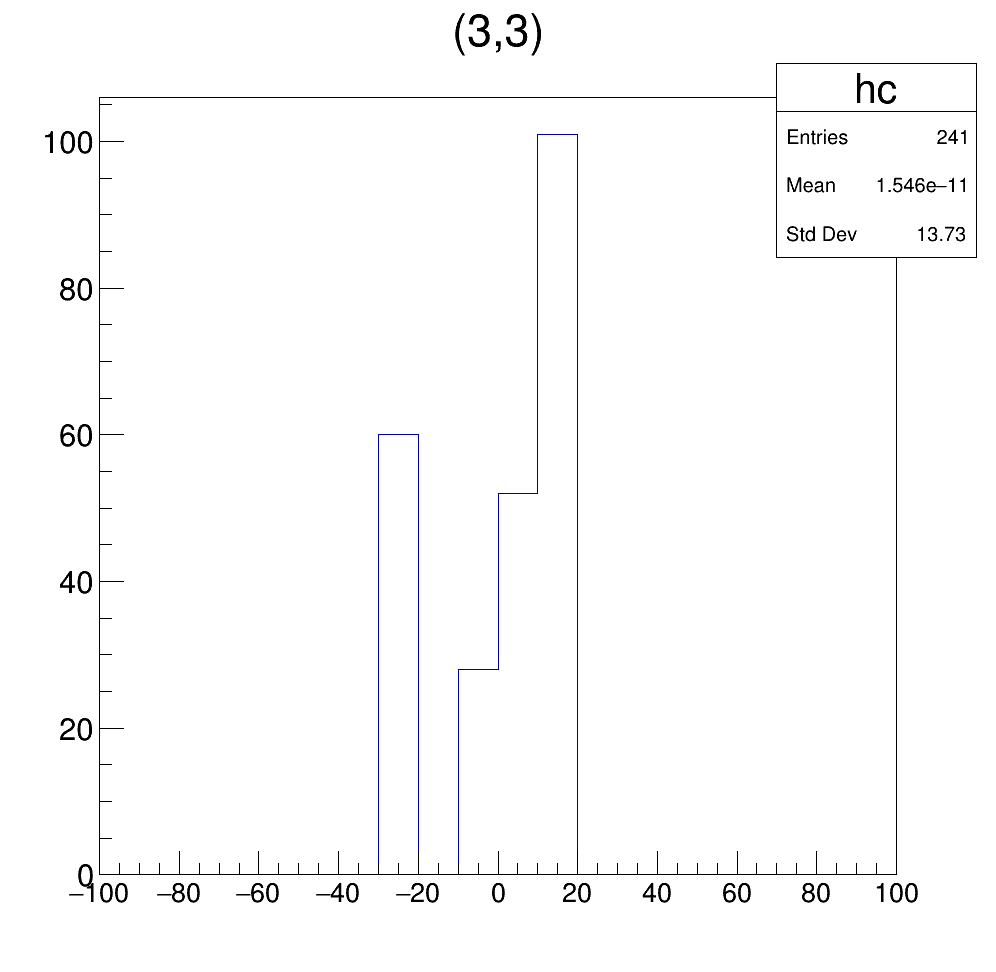

In [21]:
ROOT.gROOT.SetStyle("BELLEII")
ROOT.gStyle.SetOptFit(11)
ROOT.gStyle.SetLabelSize(0.03)
# fig, ax = plt.subplots(len(slow_frqs.keys()), figsize=(10,150))
  
table_digi_s_buf = Texttable()
table_digi_s_buf.set_cols_align(["c", "c", "c", "c"])
table_digi_s_buf_data = [["FPGA Position", "Mean", "STD", "$\\frac{\\delta f}{f_{o}}$*1e6 (ppm)"]]

for i, (k, fast_data) in enumerate(slow_frqs.items()):

    mean = np.mean(fast_data)
    mean_data = [ f-mean for f in fast_data ]
    std = np.std(mean_data)
    print(f"{k} mean {mean}, std: {std}")
    # ax[i].hist(mean_data, label=k)
                       
    # fast_m = np.mean(fast_data)
    # print(f"found fast mean: {fast_m}")
    # diff_data = np.array([r-fast_m for r in fast_data], dtype=np.double) 

    c = ROOT.TCanvas("c", "c", 1000, 1000) 
    comb_hist = ROOT.TH1D("hc", "hc", 20, -100, 100)
    comb_hist.SetDirectory(0)
    for nd in mean_data:
        comb_hist.Fill(nd)
    
    comb_hist.SetTitle(f"{k}")
    # fit doesn't work for slow
    # comb_hist.Fit("gaus", "q")
    # std = comb_hist.GetFunction("gaus").GetParameter("Sigma")
    table_digi_s_buf_data.append([k, mean, std, std/mean * 1e6])
    comb_hist.Draw()
    
    c.Draw()
    c.SaveAs(f"./pdfs/slow_{k}.pdf")
table_digi_s_buf.add_rows(table_digi_s_buf_data)
fpga_fit = latextable.draw_latex(table_digi_s_buf, caption="FPGA Calibration Results", label="tab:fpga_slow_calibration")
fpga_tex_file = "./pdfs/fpga_slow_fit.tex"
with open(fpga_tex_file, 'w') as f:
    f.write(fpga_fit)

### Plot uncertainty as function of broadcast distance

In [22]:
fast_data = table_digi_buf_data
slow_data = table_digi_s_buf_data
ind = [ fast[0] for fast in fast_data[1:] ]
sind = ind = [ fast[0] for fast in slow_data[1:] ]
assert ind == sind, "not equal ind"
print(fast_data[0])
print(fast_data[1:2], slow_data[1:2])

['FPGA Position', 'Mean', 'STD', '\\frac{\\delta f}{f_{o}}*1e6 (ppm)']
[['(0,0)', 30000245.542867467, 2.378545527613186, 0.07928420199809609]] [['(0,0)', 30000243.222617082, 3.8951957385164078, 0.1298388052927462]]


3.5122496949043125 1.0513287103670304


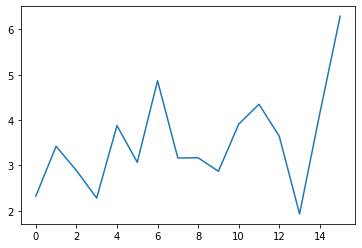

In [23]:
mean_diff = [ fast[1] - slow[1] for fast, slow in zip(fast_data[1:], slow_data[1:]) ]

plt.plot(mean_diff)
ind = []
print(np.mean(mean_diff), np.std(mean_diff))

['(0,0)', '(0,1)', '(0,2)', '(0,3)', '(1,0)', '(1,1)', '(1,2)', '(1,3)', '(2,0)', '(2,1)', '(2,2)', '(2,3)', '(3,0)', '(3,1)', '(3,2)', '(3,3)']


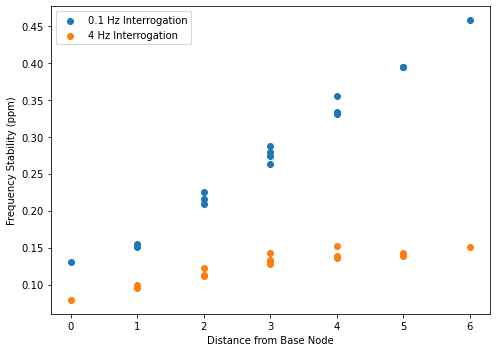

In [24]:
slow_ppm = [ slow[3] for slow in slow_data[1:] ]
fast_ppm = [ fast[3] for fast in fast_data[1:] ]
labels = [ label[0] for label in slow_data[1:] ]
print(labels)
x = [ 0 , 1 , 2, 3 , 1 , 2 , 3, 4, 2, 3, 4, 5, 3, 4, 5, 6]

# x = np.arange(0,len(slow_ppm))
fig, ax = plt.subplots(figsize=(7,5))
sa, sb = np.polyfit(x, slow_ppm, 1)
fa, fb = np.polyfit(x, fast_ppm, 1)


ax.scatter(x, slow_ppm, label="0.1 Hz Interrogation")
ax.scatter(x, fast_ppm, label="4 Hz Interrogation")
fit_x = np.linspace(0, max(x), num=50)
ax.set_xlabel("Distance from Base Node")
ax.set_ylabel("Frequency Stability (ppm)")
ax.legend()
plt.tight_layout()
plt.savefig("./pdfs/interrogation_ppm_diff.pdf")

### How to get Histo under/overflow

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TCanvas::Constructor>:

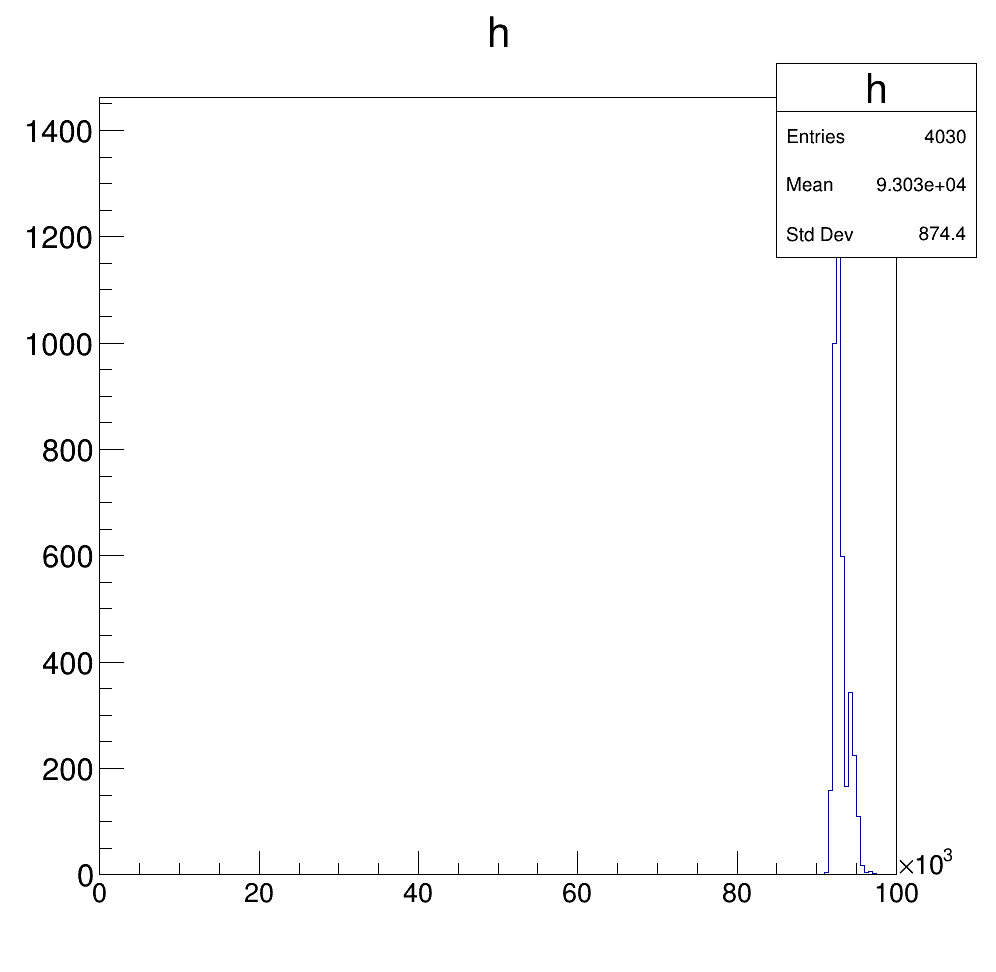

In [25]:
for k, fast_data in fast_packetTs.items():
    # m = np.mean(fast_data)
    # diff_data = np.array([r-m for r in fast_data], dtype=np.double) 

    # print(diff_data[:10])
    c = ROOT.TCanvas("c", "c", 1000, 1000)
    h = ROOT.TH1D("h", "h", 200, -40, 100000)
    h.SetDirectory(0)
    for d in fast_data:
        h.Fill(d)
    # h.Fit("gaus")
    h.Draw()
    c.Draw()
    # c.SaveAs(f"./pdfs/{k}_packet.pdf")

In [26]:
h = ROOT.TH1D("h", "h", 2, -1, 1)
h.Fill(-2)
h.Fill(2)
h.Fill(3)
print(h.GetBinContent(0))
print(h.GetBinContent(h.GetNbinsX()+1))
print(h.GetNbinsX()+1)
h.Print("all")

1.0
2.0
3
TH1.Print Name  = h, Entries= 3, Total sum= 0
 fSumw[0]=1, x=-1.5
 fSumw[1]=0, x=-0.5
 fSumw[2]=0, x=0.5
 fSumw[3]=2, x=1.5
